In [ ]:
# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

1.Loading Dataset and Preprocessing

In [3]:
#Loading Dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target variable
df['HouseValue'] = housing.target

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
#Explore the dataset

In [4]:
print(df.shape)

(20640, 9)


In [5]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude    HouseValue  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [9]:
print(df.info)

<bound method DataFrame.info of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       

This step helps us understand:
 Number of rows and columns
 Data types of variables
 Statistical summary of features

In [ ]:
#Checking null values

In [7]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HouseValue    0
dtype: int64


Observation:
  Here there is no null values found. For numerical values null exists, replace the value with mean

In [ ]:
#Seperate the feature and target variable

In [9]:
X= df.drop('HouseValue',axis=1)
y= df['HouseValue']

In [24]:
#split the data into 80% training data and 20% test data

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
#Feature Scaling

In [11]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

Different features have different ranges. 
For example:
Population may be in thousands.
Income may have much smaller values.

Scaling standardizes the data and improves model performance.

    Formula Used
        Z=  Standard Deviation/X− Mean
  

2. Algorithm Implementation

In [30]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

How Linear Regression Works
Linear regression is a foundational statistical and supervised machine learning algorithm used to predict a continuous outcome by modeling the relationship between a dependent variable and one or more independent variables. It finds the "best-fit" straight line that minimizes the error between predicted and actual values.

Why Linear Regression is Suitable
    Simple and easy to interpret.
    Fast to train.
    Provides a good baseline model for housing price prediction.


3. Model Evaluation

In [19]:
mse = mean_squared_error(y_test, y_pred)
print("MSE",mse)

MSE 0.5558915986952444


In [20]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE",mae)

MAE 0.5332001304956565


In [22]:
r2 = r2_score(y_test, y_pred)
print("R2 Score",r2)

R2 Score 0.5757877060324508


In [ ]:
#Visualise Model

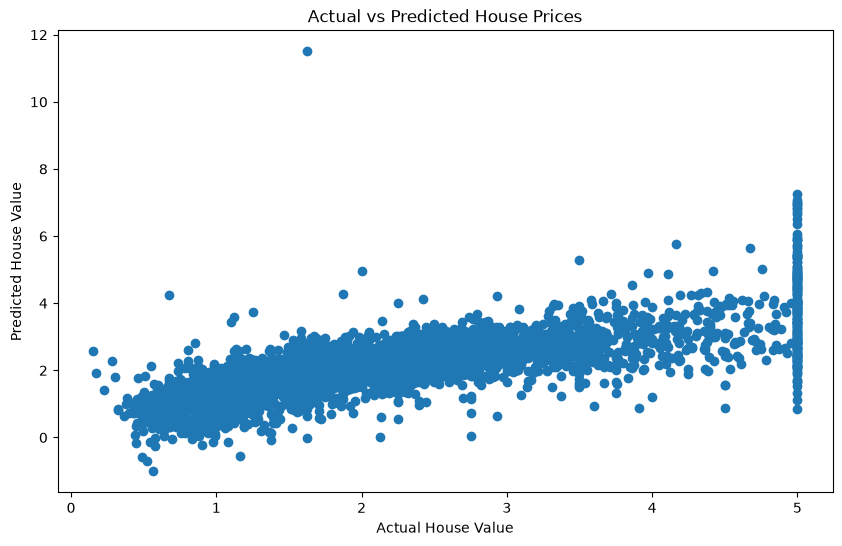

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Prices")

plt.show()